# SMS Spam Detection using Machine Learning

In [2]:
# Importing Required Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
df=pd.read_csv("C:/Elizabeth/Study/ML Datasets/spam_sms.csv")

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5572 entries, 0 to 5571
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   v1      5572 non-null   object
 1   v2      5572 non-null   object
dtypes: object(2)
memory usage: 87.2+ KB


In [5]:
df.describe()

,v1,v2
count,5572,5572
unique,2,5169
top,ham,"Sorry, I'll call later"
freq,4825,30


In [6]:
df.head()

,v1,v2
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."


In [7]:
df.isna().sum()


v1    0
v2    0
dtype: int64

In [8]:
df.duplicated().sum()

np.int64(403)

In [9]:
df.drop_duplicates(inplace=True)

Text preprocessing

In [ ]:
import nltk
import re
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from nltk.stem.porter import PorterStemmer
from sklearn.feature_extraction.text import TfidfVectorizer
nltk.download('wordnet')
nltk.download('stopwords')
nltk.download('omw-1.4')

[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\Elizabeth\AppData\Roaming\nltk_data...
[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\Elizabeth\AppData\Roaming\nltk_data...
[nltk_data]   Unzipping corpora\stopwords.zip.
[nltk_data] Downloading package omw-1.4 to
[nltk_data]     C:\Users\Elizabeth\AppData\Roaming\nltk_data...


True

In [15]:
lm =WordNetLemmatizer()

In [16]:
# cleaning the text
def pre_processing (word):
  word=re.sub("[^a-zA-Z]",' ',word) # remove punctuat
  word=word.lower().split() # split the sentance to be every word alone (tokenzing)
  word=[lm.lemmatize(word) for word in word if word not in stopwords.words('english')] # Lemmatization every word and remove stop words
  word=' '.join(word)
  return word

In [17]:
df['v2'][3]

'U dun say so early hor... U c already then say...'

In [18]:
# test the function
pre_processing('U dun say so early hor... U c already then say...')

'u dun say early hor u c already say'

In [19]:
# apply it on the DataFrame
df['pre_processing']=df['v2'].apply(pre_processing)

In [20]:
df

,v1,v2,spam,pre_processing
0,ham,"Go until jurong point, crazy.. Available only ...",0,go jurong point crazy available bugis n great ...
1,ham,Ok lar... Joking wif u oni...,0,ok lar joking wif u oni
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...,1,free entry wkly comp win fa cup final tkts st ...
3,ham,U dun say so early hor... U c already then say...,0,u dun say early hor u c already say
4,ham,"Nah I don't think he goes to usf, he lives aro...",0,nah think go usf life around though
...,...,...,...,...
5567,spam,This is the 2nd time we have tried 2 contact u...,1,nd time tried contact u u pound prize claim ea...
5568,ham,Will Ì_ b going to esplanade fr home?,0,b going esplanade fr home
5569,ham,"Pity, * was in mood for that. So...any other s...",0,pity mood suggestion
5570,ham,The guy did some bitching but I acted like i'd...,0,guy bitching acted like interested buying some...


Modelling

In [21]:
from sklearn.feature_extraction.text import TfidfVectorizer,CountVectorizer
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, f1_score
from sklearn.pipeline import Pipeline,make_pipeline
from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.model_selection import GridSearchCV,RandomizedSearchCV

import warnings
warnings.filterwarnings('ignore')

In [22]:
x=df['pre_processing']
y=df['spam']

Splitting the data

In [25]:
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, stratify=y, random_state=42)
x_train


336                          cool come havent wined dined
390                                    huh late fr dinner
583                     ex wife able kid want kid one day
1387    hope ur head hurt much ploughing way pile iron...
1095                                   ryder unsold gibbs
                              ...                        
606     xclusive clubsaisai morow soiree speciale zouk...
105     thanks lot wish birthday thanks making birthda...
3789    love know feel make belly warm wish love shall...
1911    lol grr mom taking forever prescription pharma...
3742                 nah wednesday bring mini cheetos bag
Name: pre_processing, Length: 4135, dtype: object

In [27]:
vc=TfidfVectorizer()
x_train_vec=vc.fit_transform(x_train)
x_test_vec=vc.transform(x_test)
x_train_vec.shape

(4135, 6166)

In [30]:
models=[
    ('LR',LogisticRegression()),
    ('NB',MultinomialNB()),
    ('RF',RandomForestClassifier()),
    ('Knn',KNeighborsClassifier()),
    ('SVC',SVC())
]

In [ ]:
for model in models:
  print(model[0])
  model=model[1]
  model.fit(x_train_vec,y_train)
  y_pred=model.predict(x_test_vec)
  report_cls = classification_report(y_test, y_pred)
  print(report_cls)
  print('-'*30)

LR
              precision    recall  f1-score   support

           0       0.96      1.00      0.98       903
           1       1.00      0.69      0.82       131

    accuracy                           0.96      1034
   macro avg       0.98      0.85      0.90      1034
weighted avg       0.96      0.96      0.96      1034

------------------------------
NB
              precision    recall  f1-score   support

           0       0.96      1.00      0.98       903
           1       0.98      0.73      0.84       131

    accuracy                           0.96      1034
   macro avg       0.97      0.87      0.91      1034
weighted avg       0.96      0.96      0.96      1034

------------------------------
RF
              precision    recall  f1-score   support

           0       0.98      1.00      0.99       903
           1       0.99      0.84      0.91       131

    accuracy                           0.98      1034
   macro avg       0.98      0.92      0.95      1034
wei

Plotting

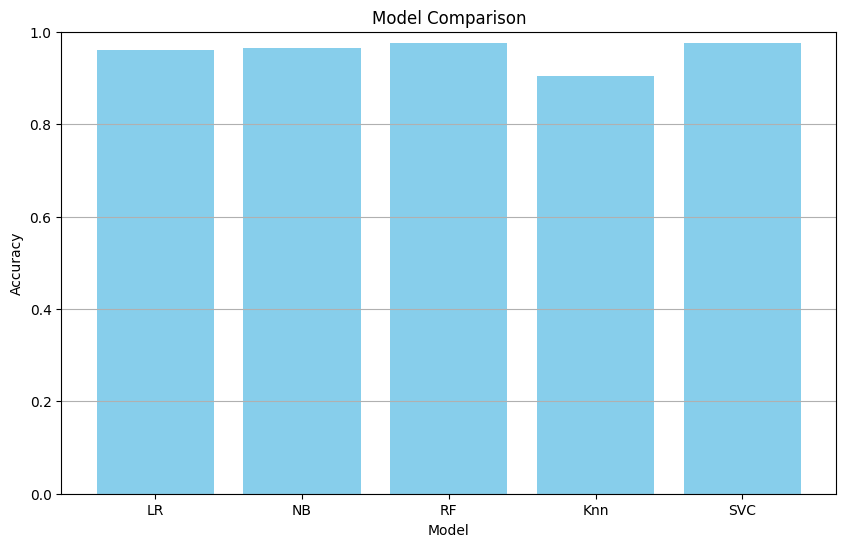

In [ ]:
import matplotlib.pyplot as plt
# Unpack model names and scores from collected results
model_names, accuracies = zip(*model_scores)

plt.figure(figsize=(10,6))
plt.bar(model_names, accuracies, color='skyblue')
plt.xlabel('Model')
plt.ylabel('Accuracy')
plt.title('Model Comparison')
plt.ylim(0, 1)  # accuracy is between 0 and 1
plt.grid(axis='y')
plt.show()



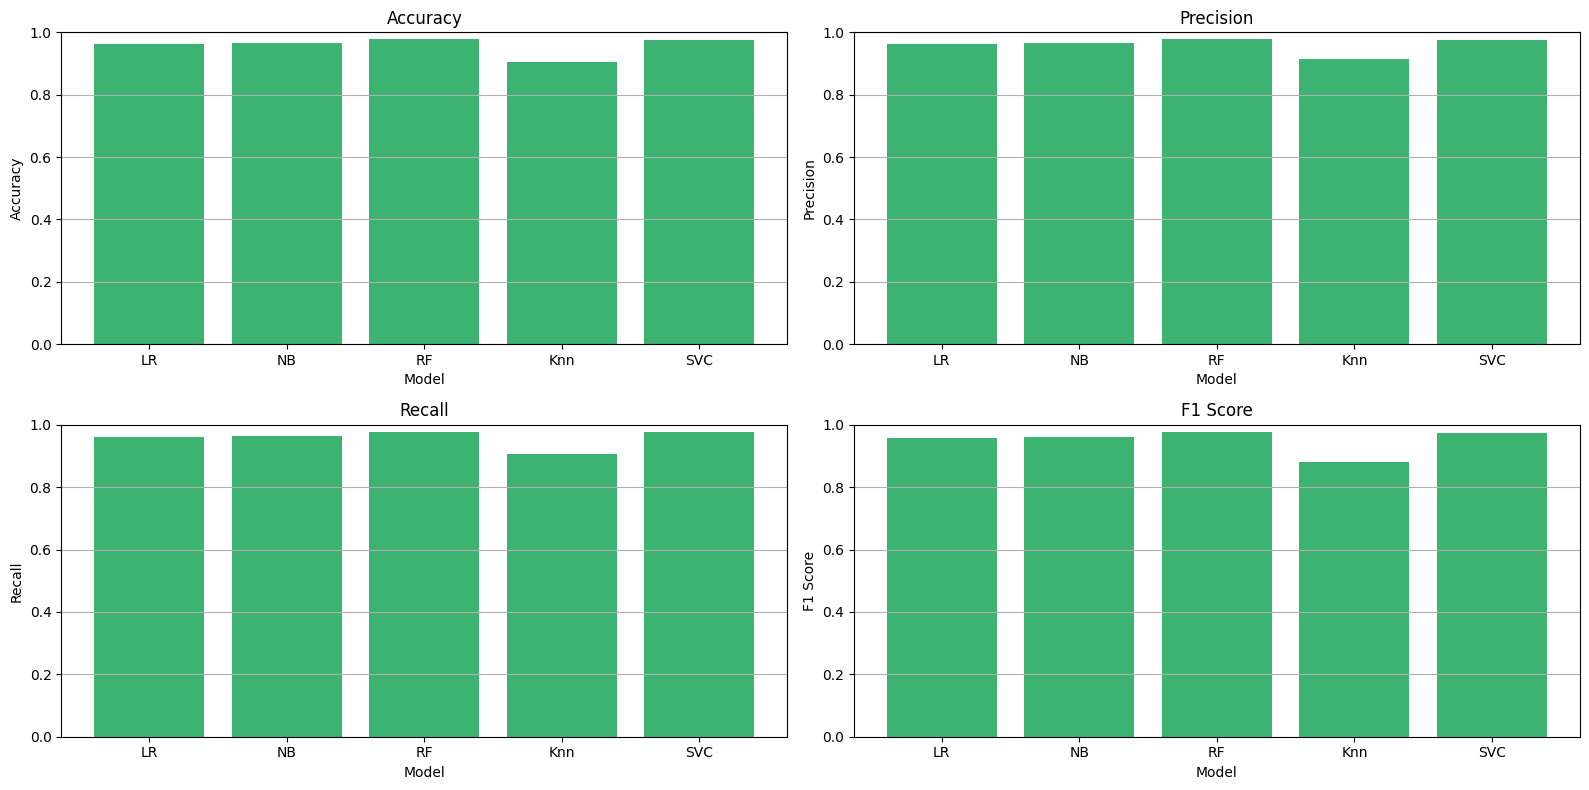

In [37]:
import matplotlib.pyplot as plt
import numpy as np

# Unpack model names and metric columns
model_names = [row[0] for row in model_scores]
accuracies = [row[1] for row in model_scores]
precisions = [row[2] for row in model_scores]
recalls = [row[3] for row in model_scores]
f1_scores = [row[4] for row in model_scores]
metrics = [accuracies, precisions, recalls, f1_scores]
titles = ['Accuracy', 'Precision', 'Recall', 'F1 Score']
plt.figure(figsize=(16, 8))
for i in range(4):
    plt.subplot(2, 2, i+1)
    plt.bar(model_names, metrics[i], color='mediumseagreen')
    plt.ylim(0, 1)
    plt.title(titles[i])
    plt.xlabel('Model')
    plt.ylabel(titles[i])
    plt.grid(axis='y')
plt.tight_layout()
plt.show()
